Title: Temperature Forecasting using Recurrent Neural Networks (RNN)

In [2]:
# Import Libraries
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

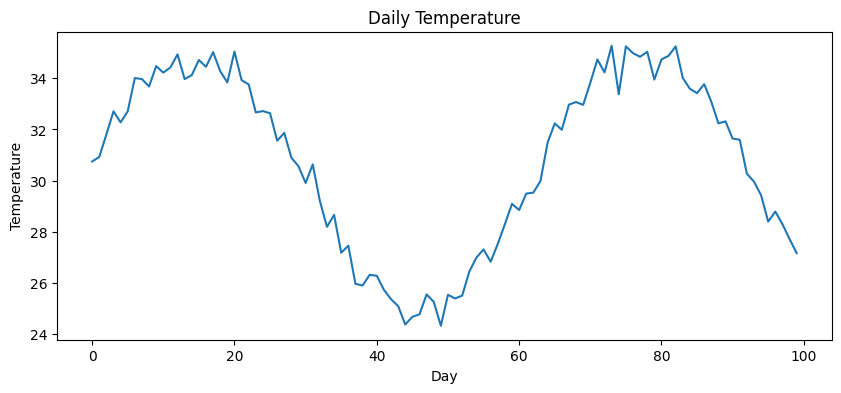

In [3]:
# Generating Data
days = np.arange(1,101)

temperature = (
    30
    + 5*np.sin(days/10)
    + np.random.normal(0,0.5,100)
)

plt.figure(figsize=(10,4))
plt.plot(temperature)
plt.title("Daily Temperature")
plt.xlabel("Day")
plt.ylabel("Temperature")
plt.show()

In [4]:
# Creating Dataset
window_size = 5

def create_dataset(data, window):

    X = []
    y = []

    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])

    return np.array(X), np.array(y)

X, y = create_dataset(
    temperature,
    window_size
)

print(X.shape)
print(y.shape)

(95, 5)
(95,)


In [5]:
# Normalize
max_val = temperature.max()

X_norm = X / max_val
y_norm = y / max_val

X_tensor = torch.tensor(
    X_norm,
    dtype=torch.float32
).unsqueeze(-1)

y_tensor = torch.tensor(
    y_norm,
    dtype=torch.float32
).unsqueeze(-1)

print(X_tensor.shape)

torch.Size([95, 5, 1])


In [6]:
# Build RNN
class TempRNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        self.fc = nn.Linear(
            32,
            1
        )

    def forward(self,x):

        out,_ = self.rnn(x)

        out = out[:,-1,:]

        return self.fc(out)

model = TempRNN()

print(model)

TempRNN(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [8]:
# Train Model
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

loss_history = []

epochs = 300

for epoch in range(epochs):

    optimizer.zero_grad()

    output = model(X_tensor)

    loss = criterion(
        output,
        y_tensor
    )

    loss.backward()

    optimizer.step()

    loss_history.append(
        loss.item()
    )

    if (epoch+1)%50==0:
        print(
            epoch+1,
            loss.item()
        )

50 0.0025030651595443487
100 0.001104080001823604
150 0.0008751290151849389
200 0.0007074283785186708
250 0.0005911460029892623
300 0.000508058990817517


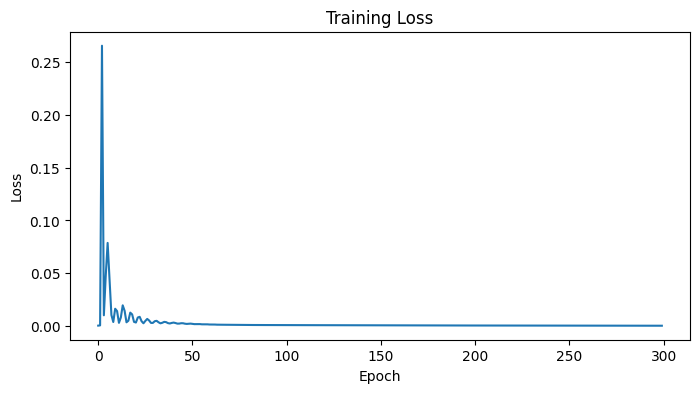

In [9]:
# Loss Graph
plt.figure(figsize=(8,4))

plt.plot(loss_history)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

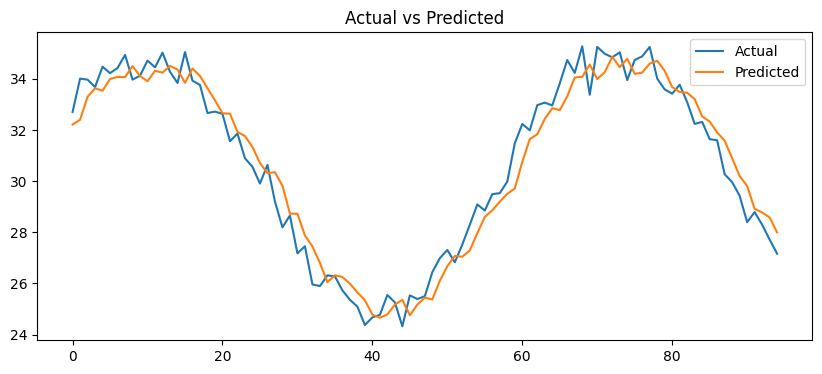

In [10]:
# Prediction
model.eval()

with torch.no_grad():

    preds = (
        model(X_tensor)
        .squeeze()
        .numpy()
        * max_val
    )

plt.figure(figsize=(10,4))

plt.plot(
    y,
    label="Actual"
)

plt.plot(
    preds,
    label="Predicted"
)

plt.legend()

plt.title(
    "Actual vs Predicted"
)

plt.show()

In [11]:
# Predict Future Temperature
last_values = temperature[-5:]

arr = torch.tensor(
    last_values/max_val,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(-1)

with torch.no_grad():

    next_temp = (
        model(arr)
        .item()
        * max_val
    )

print(
    "Predicted Next Day Temperature:",
    round(next_temp,2)
)

Predicted Next Day Temperature: 27.57


Conclusion: This project implemented a Recurrent Neural Network (RNN) for temperature forecasting. Synthetic daily temperature data was generated and converted into sequential windows. The RNN learned patterns from previous temperature values and successfully predicted future temperatures. The loss decreased significantly during training, showing effective learning. The project demonstrates how RNNs can be applied to time-series forecasting problems. However, RNNs may struggle with very long sequences due to the vanishing gradient problem.
